In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import pickle
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical

2024-04-21 18:18:42.666207: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-21 18:18:42.666307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-21 18:18:42.804670: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for class_label, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            img = Image.open(img_path)
            img = img.resize((64, 64))  
            img = np.array(img)
            if img is not None:
                images.append(img)
                labels.append(class_label)
    return np.array(images), np.array(labels)

# Assuming your dataset is stored in a folder called 'dataset'
dataset_folder = '/kaggle/input/paddydoctormedium'

# Load images and labels from the dataset folder
x_data, y_data = load_images_from_folder(dataset_folder)

# Shuffle the data
random_indices = np.random.permutation(len(x_data))
x_data = x_data[random_indices]
y_data = y_data[random_indices]

# Split the data into training and testing sets (assuming 80-20 split)
split_idx = int(0.8 * len(x_data))
x_train, x_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# Normalize the pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [4]:
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (12980, 12288)
Testing data shape: (3245, 12288)
Training labels shape: (12980,)
Testing labels shape: (3245,)


In [3]:
from collections import Counter

before_smote_distribution = Counter(y_train)

In [4]:
borderline_smote = SMOTE(random_state=42)
x_train_bls, y_train_bls = borderline_smote.fit_resample(x_train, y_train)

In [7]:
after_smote_distribution = Counter(y_train_bls)  # Assuming y_train_smote contains the labels after SMOTE


In [8]:
labels_before = list(before_smote_distribution.keys())
counts_before = list(before_smote_distribution.values())

In [9]:
labels_after = list(after_smote_distribution.keys())
counts_after = list(after_smote_distribution.values())

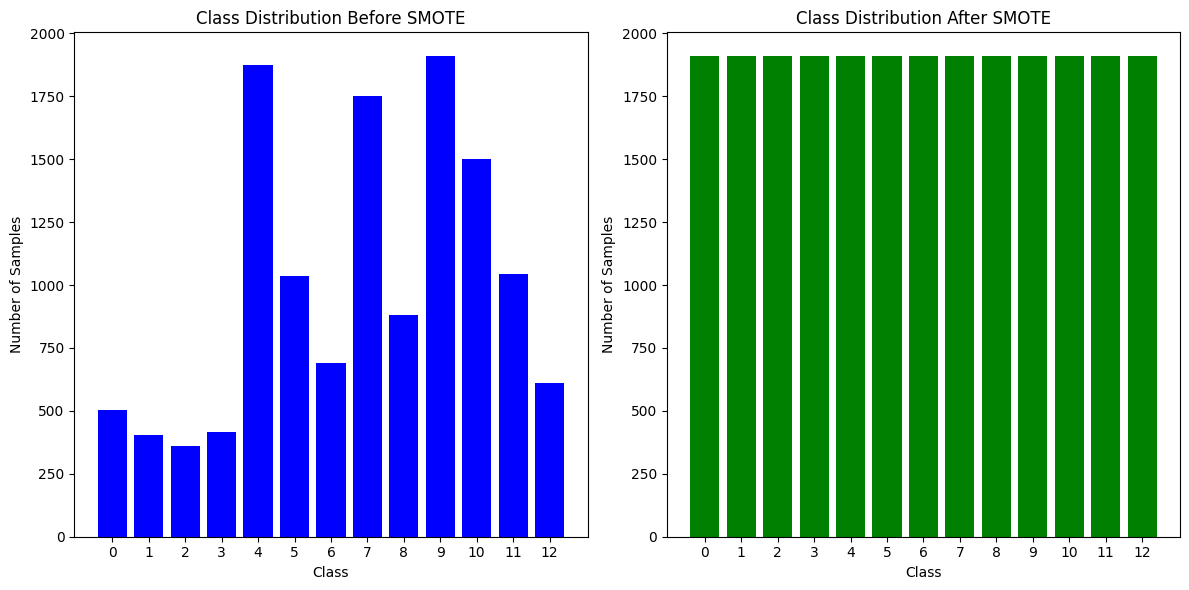

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Before SMOTE
ax1.bar(labels_before, counts_before, color='blue')
ax1.set_title('Class Distribution Before SMOTE')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(labels_before)

# After SMOTE
ax2.bar(labels_after, counts_after, color='green')
ax2.set_title('Class Distribution After SMOTE')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(labels_after)

plt.tight_layout()
plt.show()

In [12]:
print("training data after bls:",x_train_bls.shape)
print("training labels after bls:",y_train_bls.shape)

training data after bls: (24817, 12288)
training labels after bls: (24817,)


In [5]:
x_train_bls = x_train_bls.astype('float32')
x_train_bls /= 255
x_train_bls = x_train_bls.reshape((len(x_train_bls), np.prod(x_train_bls.shape[1:])))
x_test = x_test.astype('float32')
x_test /= 255
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [10]:
num_classes = len(np.unique(y_train_bls))
y_train_one_hot = to_categorical(y_train_bls, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

In [7]:
x_train_bls = x_train_bls.reshape(-1, 64, 64, 3)
x_test = x_test.reshape(-1, 64, 64, 3)


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data generator with augmentation options
datagen = ImageDataGenerator(
    rotation_range=20,      # Random rotation in the range [-20, 20] degrees
    width_shift_range=0.1,  # Random horizontal shift by 10% of the width
    height_shift_range=0.1, # Random vertical shift by 10% of the height
    shear_range=0.2,        # Shear intensity (shear angle in radians)
    zoom_range=0.2,         # Random zoom by 20%
    horizontal_flip=True,   # Random horizontal flip
    fill_mode='nearest'     # Fill mode for points outside the input boundaries
)

In [9]:
datagen.fit(x_train_bls)

# Example of using the data generator to augment data during training
augmented_data_generator = datagen.flow(x_train_bls, y_train_bls, batch_size=32)

# Octave Convolution


In [11]:
from keras.layers import Conv2D, AveragePooling2D, UpSampling2D
from keras.layers import add


def initial_octconv(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                    alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Initializes the Octave Convolution architecture.

    Accepts a single input tensor, and returns a pair of tensors.
    The first tensor is the high frequency pathway.
    The second tensor is the low frequency pathway.

    # Arguments:
        ip: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    high_low_filters = int(alpha * filters)
    high_high_filters = filters - high_low_filters

    if strides[0] > 1:
        ip = AveragePooling2D()(ip)

    # High path
    x_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                    dilation_rate=dilation, use_bias=bias,
                    kernel_initializer='he_normal')(ip)

    # Low path
    x_high_low = AveragePooling2D(pool_size=(2, 2))(ip)
    x_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                   dilation_rate=dilation, use_bias=bias,
                   kernel_initializer='he_normal')(x_high_low)

    return x_high, x_low


def final_octconv(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', dilation=None, bias=False):
    """
    Ends the Octave Convolution architecture.

    Accepts two input tensors, and returns a single output tensor.
    The first input tensor is the high frequency pathway.
    The second input tensor is the low frequency pathway.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a single Keras tensor:
            - x_high: The merged high frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    if strides[0] > 1:
        avg_pool = AveragePooling2D(pool_size=(2, 2))

        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    # Low path
    x_low_high = Conv2D(filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)

    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Merge paths
    x = add([x_high_high, x_low_high])

    return x


def octconv_block(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Constructs an Octave Convolution block.

    Accepts a pair of input tensors, and returns a pair of tensors.
    The first tensor is the high frequency pathway for both ip/op.
    The second tensor is the low frequency pathway for both ip/op.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    low_low_filters = high_low_filters = int(alpha * filters)
    high_high_filters = low_high_filters = filters - low_low_filters

    avg_pool = AveragePooling2D(pool_size=(2, 2))

    if strides[0] > 1:
        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    x_low_high = Conv2D(low_high_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)
    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Low path
    x_low_low = Conv2D(low_low_filters, kernel_size, padding=padding,
                       dilation_rate=dilation, use_bias=bias,
                       kernel_initializer='he_normal')(ip_low)

    x_high_low = avg_pool(ip_high)
    x_high_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(x_high_low)

    # Merge paths
    x_high = add([x_high_high, x_low_high])
    x_low = add([x_low_low, x_high_low])

    return x_high, x_low


if __name__ == '__main__':

    visualize_model = True

    from keras.models import Model
    from keras.layers import Input

    ip = Input(shape=(32, 32, 3))

    xh, xl = initial_octconv(ip, filters=48)

    xh, xl = octconv_block(xh, xl, filters=64)
    xh, xl = octconv_block(xh, xl, filters=96, strides=(2, 2))

    x = final_octconv(xh, xl, filters=10)

    model = Model(ip, x)
    model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 16, 16, 3) │          0 │ input_layer[0][0] │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │        648 │ average_pooling2… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        648 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │      6,912 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      6,912 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (AveragePooling2D)  │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_2[0][0],   │
│                     │ 32)               │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      6,912 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      6,912 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 8, 8, 32)  │          0 │ add[0][0],        │
│ (AveragePooling2D)  │                   │            │ add_1[0][0],      │
│                     │                   │            │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 16,    │          0 │ conv2d_4[0][0],   │
│                     │ 32)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 48)  │     13,824 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 48)  │     13,824 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 48)  │     13,824 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     13,824 │ average_pooling2… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 92,880 (362.81 KB)

 Trainable params: 92,880 (362.81 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'



from keras.layers import ReLU, BatchNormalization
from keras import backend as K



def initial_oct_conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                             alpha=0.5, padding='same', dilation=None, bias=False,
                             activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = initial_octconv(ip, filters, kernel_size, strides, alpha,
                                    padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low


def final_oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                           padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = final_octconv(ip_high, ip_low, filters, kernel_size, strides,
                      padding, dilation, bias)

    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                     alpha=0.5, padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = octconv_block(ip_high, ip_low, filters, kernel_size, strides, alpha,
                                  padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low

In [15]:
import os
from keras.layers import BatchNormalization
from keras.layers import Conv2D
from keras.layers import Dense
from keras.layers import GlobalAveragePooling2D
from keras.layers import GlobalMaxPooling2D
from keras.layers import Input
from keras.layers import MaxPool2D
from keras.layers import ReLU
from keras.layers import add
from keras.models import Model
from keras.utils import get_source_inputs

from keras import backend as K
from keras_applications.imagenet_utils import _obtain_input_shape



def _conv_block(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                padding='same', bias=False):
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=bias,
               kernel_initializer='he_normal')(ip)

    return x


def _conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = _conv_block(ip, filters, kernel_size, strides, padding, bias)
    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def _octresnet_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                downsample_shortcut=False, first_block=False,
                                expansion=4):

    if first_block:
        x_high_res, x_low_res = initial_oct_conv_bn_relu(ip, filters, kernel_size=(1, 1),
                                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    else:
        x_high_res, x_low_res = ip
        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    final_out_filters = int(filters * expansion)
    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters=final_out_filters,
                                     kernel_size=(1, 1), alpha=alpha, activation=False)

    if downsample_shortcut:
        x_high_res, x_low_res = oct_conv_bn_relu(x_high_res, x_low_res,
                                                 final_out_filters, kernel_size=(1, 1),
                                                 strides=strides, alpha=alpha,
                                                 activation=False)

    x_high = add([x_high, x_high_res])
    x_low = add([x_low, x_low_res])

    x_high = ReLU()(x_high)
    x_low = ReLU()(x_low)

    return x_high, x_low


def _octresnet_final_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                      downsample_shortcut=False,
                                      expansion=4):

    x_high_res, x_low_res = ip

    x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                     alpha=alpha)

    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                     strides=strides, alpha=alpha)

    final_filters = int(filters * expansion)
    x_high = final_oct_conv_bn_relu(x_high, x_low, final_filters, kernel_size=(1, 1),
                                    activation=False)

    if downsample_shortcut:
        x_high_res = final_oct_conv_bn_relu(x_high_res, x_low_res, final_filters, kernel_size=(1, 1),
                                            strides=strides, activation=False)

    x = add([x_high, x_high_res])
    x = ReLU()(x)

    return x


def _bottleneck_original(ip, filters, strides=(1, 1), downsample_shortcut=False,
                         expansion=4):

    final_filters = int(filters * expansion)

    shortcut = ip

    x = _conv_bn_relu(ip, filters, kernel_size=(1, 1))
    x = _conv_bn_relu(x, filters, kernel_size=(3, 3), strides=strides)
    x = _conv_bn_relu(x, final_filters, kernel_size=(1, 1), activation=False)

    if downsample_shortcut:
        shortcut = _conv_block(shortcut, final_filters, kernel_size=(1, 1),
                               strides=strides)

    x = add([x, shortcut])
    x = ReLU()(x)

    return x


def OctaveResNet(layers,
                 include_top=True,
                 weights=None,
                 input_tensor=None,
                 input_shape=None,
                 pooling=None,
                 classes=1000,
                 alpha=0.5,
                 expansion=1,
                 initial_filters=64,
                 initial_strides=False,
                 **kwargs):
    """ Instantiates a Octave ResNet architecture.

    # Arguments
        layers: list of integers defining the depth of the network and
            the number of octave conv blocks per level of the
            network.
        include_top: whether to include the fully-connected
            layer at the top of the network.
        weights: one of `None` (random initialization),
              'imagenet' (pre-training on ImageNet),
              or the path to the weights file to be loaded.
        input_tensor: optional Keras tensor
            (i.e. output of `layers.Input()`)
            to use as image input for the model.
        input_shape: optional shape tuple, only to be specified
            if `include_top` is False (otherwise the input shape
            has to be `(224, 224, 3)` (with `'channels_last'` data format)
            or `(3, 224, 224)` (with `'channels_first'` data format).
            It should have exactly 3 inputs channels,
            and width and height should be no smaller than 32.
            E.g. `(200, 200, 3)` would be one valid value.
        pooling: optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
        classes: optional number of classes to classify images
            into, only to be specified if `include_top` is True, and
            if no `weights` argument is specified.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        expansion: int/float. Multiplicative factor to increase the
            number of filters in each octave block.
        initial_filters: number of filters in the first convolution
            layer. Determines how many parameters the network will
            have.
        initial_strides: bool to determine whether to apply a strided
            convolution and max pooling before any octave conv
            block. Set to True for ImageNet models and False for
            CIFAR models.

    # Returns
        A Keras model instance.

    # Raises
        ValueError: in case of invalid argument for `weights`,
            or invalid input shape.
`       ValueError: If `alpha` is < 0 or > 1.
        ValueError: If `layers` is not a list or a tuple
            of integers.
    """

    if not (weights in {'imagenet', None} or os.path.exists(weights)):
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization), `imagenet` '
                         '(pre-training on ImageNet), '
                         'or the path to the weights file to be loaded.')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as `"imagenet"` with `include_top`'
                         ' as true, `classes` should be 1000')

    if alpha < 0. or alpha > 1.:
        raise ValueError('`alpha` must be between 0 and 1. Current alpha = '
                         '%f' % alpha)

    if type(layers) not in [list, tuple]:
        raise ValueError('`layers` must be a list/tuple of integers. '
                         'Current layers = ', layers)

    # Force convert all layer values to integers
    layers = [int(x) for x in layers]

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top,
                                      weights=weights)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    if initial_strides:
        initial_strides = (2, 2)

    else:
        initial_strides = (1, 1)

    x = _conv_bn_relu(img_input, filters=64, kernel_size=(7, 7), strides=initial_strides)

    if initial_strides:
        x = MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)

    num_filters = initial_filters
    num_blocks = len(layers)

    for i in range(num_blocks - 1):
        for j in range(layers[i]):
            if j == 0:
                strides = (2, 2)
                downsample_shortcut = True

            else:
                strides = (1, 1)
                downsample_shortcut = False

            # first block has no downsample, no shortcut
            if i == 0 and j == 0:
                first_block = True
                strides = (1, 1)
                downsample_shortcut = True

            else:
                first_block = False

            x = _octresnet_bottleneck_block(x, num_filters, alpha, strides, downsample_shortcut,
                                            first_block, expansion)

        # double number of filters per block
        num_filters *= 2

    # final block
    for j in range(layers[-1]):
        if j == 0:
            strides = (2, 2)
            x = _octresnet_final_bottleneck_block(x, num_filters, alpha, strides,
                                                  downsample_shortcut=True, expansion=expansion)

        else:
            strides = (1, 1)
            x = _bottleneck_original(x, num_filters, strides, expansion=expansion)

    if include_top:
        x = GlobalAveragePooling2D(name='avg_pool')(x)
        x = Dense(classes, activation='softmax', name='fc')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D(name='avg_pool')(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D(name='max_pool')(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input

    model = Model(inputs, x, name='OctaveResNet')

    return model


def OctaveResNet50(include_top=True,
                   weights=None,
                   input_tensor=None,
                   input_shape=None,
                   pooling=None,
                   classes=1000,
                   alpha=0.5,
                   expansion=4,
                   initial_filters=64,
                   initial_strides=True,
                   **kwargs):

    return OctaveResNet([3, 4, 6, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet101(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 4, 23, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet152(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 8, 36, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


if __name__ == '__main__':
    model = OctaveResNet50(input_shape=(256, 256, 3), classes=1000,
                           alpha=0.125, expansion=4,
                           initial_filters=64,
                           initial_strides=True)
   

In [16]:
model2 = OctaveResNet50(include_top=True,
                        weights=None,
                        input_tensor=None,
                        input_shape=(64,64,3),
                        pooling='avg',
                        classes=13,
                        alpha=0.125,
                        expansion=4,
                        initial_filters=64,
                        initial_strides=True)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
model3 = OctaveResNet101(include_top=True,
                        weights=None,
                        input_tensor=None,
                        input_shape=(64,64,3),
                        pooling='avg',
                        classes=13,
                        alpha=0.125,
                        expansion=4,
                        initial_filters=64,
                        initial_strides=True)
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
model4 = OctaveResNet152(include_top=True,
                        weights=None,
                        input_tensor=None,
                        input_shape=(64,64,3),
                        pooling='avg',
                        classes=13,
                        alpha=0.125,
                        expansion=4,
                        initial_filters=64,
                        initial_strides=True)
model4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.969:
            self.model.stop_training = True

# Instantiate the custom callback
callback = CustomCallback()

# Train the model 
history = model2.fit(x_train_bls,y_train_one_hot,epochs=60,batch_size=32,validation_data=(x_test,y_test_one_hot),callbacks=callback)

Epoch 1/60
  2/786 ━━━━━━━━━━━━━━━━━━━━ 1:17 98ms/step - accuracy: 0.9922 - loss: 0.1197   

W0000 00:00:1713726067.075603     119 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9430 - loss: 0.2371

W0000 00:00:1713726180.575431     122 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


786/786 ━━━━━━━━━━━━━━━━━━━━ 174s 147ms/step - accuracy: 0.9431 - loss: 0.2370 - val_accuracy: 0.8407 - val_loss: 0.6802
Epoch 2/60
786/786 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9842 - loss: 0.0493 - val_accuracy: 0.9285 - val_loss: 0.3443
Epoch 3/60
786/786 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9666 - loss: 0.1221 - val_accuracy: 0.8968 - val_loss: 0.5120
Epoch 4/60
786/786 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9900 - loss: 0.0327 - val_accuracy: 0.8619 - val_loss: 0.5964
Epoch 5/60
786/786 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.9903 - loss: 0.0324 - val_accuracy: 0.8838 - val_loss: 0.4908
Epoch 6/60
540/786 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.9740 - loss: 0.1090

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    patience=10, 
    restore_best_weights=True,
)

# Train the model 
history3 = model3.fit(x_train_bls,y_train_one_hot,epochs=40,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=early_stopping)

Epoch 1/40


I0000 00:00:1713592940.431972     129 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1713592940.858887     129 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3167 - loss: 2.5958

W0000 00:00:1713593189.418174     129 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.3168 - loss: 2.5951

W0000 00:00:1713593213.636747     130 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1713593235.438631     129 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


388/388 ━━━━━━━━━━━━━━━━━━━━ 629s 763ms/step - accuracy: 0.3170 - loss: 2.5945 - val_accuracy: 0.0564 - val_loss: 5.0635
Epoch 2/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 66s 170ms/step - accuracy: 0.4519 - loss: 1.9315 - val_accuracy: 0.0632 - val_loss: 1911.1510
Epoch 3/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 67s 172ms/step - accuracy: 0.5473 - loss: 1.5966 - val_accuracy: 0.4524 - val_loss: 8.0739
Epoch 4/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 69s 178ms/step - accuracy: 0.6783 - loss: 1.1037 - val_accuracy: 0.6949 - val_loss: 3.6899
Epoch 5/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 67s 173ms/step - accuracy: 0.8075 - loss: 0.6591 - val_accuracy: 0.3775 - val_loss: 99.7305
Epoch 6/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.8504 - loss: 0.5212 - val_accuracy: 0.5713 - val_loss: 1.6298
Epoch 7/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 67s 173ms/step - accuracy: 0.8435 - loss: 0.5700 - val_accuracy: 0.1596 - val_loss: 103.1620
Epoch 8/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 67s 174ms/step - accuracy: 0.7411 - loss: 0.859

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    patience=10, 
    restore_best_weights=True,
)

# Train the model 
history4 = model4.fit(x_train_bls,y_train_one_hot,epochs=40,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=early_stopping)

In [20]:
loss,accuracy = model2.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

  7/102 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8453 - loss: 0.5509

W0000 00:00:1713725940.949925     119 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 129ms/step - accuracy: 0.8113 - loss: 0.7335
testing accuracy: 0.8123266696929932


W0000 00:00:1713725953.931684     122 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [25]:
loss,accuracy = model3.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7820 - loss: 0.7100
testing accuracy: 0.7790446877479553


In [ ]:
loss,accuracy = model4.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

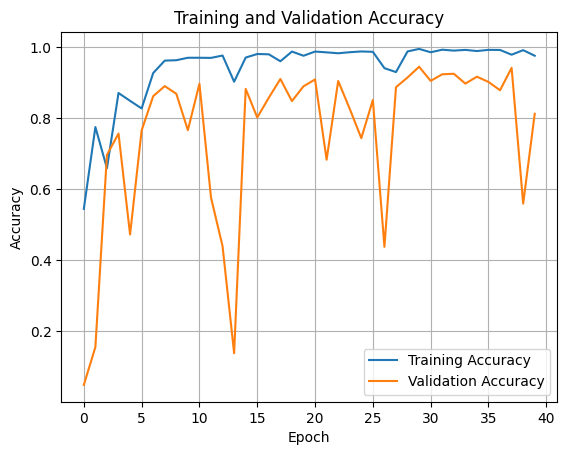

In [21]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

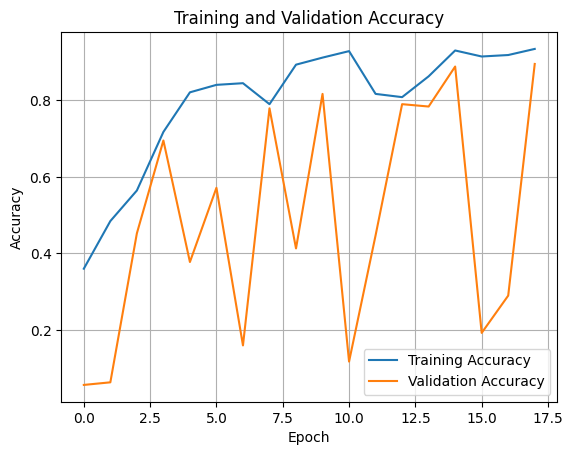

In [26]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history4.history['accuracy']
val_acc = history4.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Get predictions from your model
y_pred = model2.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert one-hot to class labels

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print or plot the confusion matrix (various ways to visualize it)
print(cm)

# Example using matplotlib for basic visualization
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Get predictions from your model
y_pred = model3.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert one-hot to class labels

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print or plot the confusion matrix (various ways to visualize it)
print(cm)

# Example using matplotlib for basic visualization
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Get predictions from your model
y_pred = model4.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert one-hot to class labels

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print or plot the confusion matrix (various ways to visualize it)
print(cm)

# Example using matplotlib for basic visualization
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()

# SparseNet

In [ ]:
'''SparseNet models for Keras.
# Reference
- [Sparsely Connected Convolutional Networks](https://arxiv.org/abs/1801.05895)
- [Github](https://github.com/lyken17/sparsenet)
'''
from __future__ import print_function
from __future__ import absolute_import
from __future__ import division
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Reshape
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D,GlobalAveragePooling2D

import numpy as np
import warnings

from keras.models import Model
from keras.layers import Input
from tensorflow.keras.layers import concatenate  # For concatenation
from tensorflow.keras.layers import add          # For addition
from tensorflow.keras.layers import BatchNormalization, LayerNormalization
from keras.regularizers import l2
from tensorflow.python.keras.utils.layer_utils import convert_dense_weights_data_format
from tensorflow.keras.utils import get_file
from tensorflow.keras.utils import get_source_inputs
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import keras.backend as K
from keras_applications.imagenet_utils import _obtain_input_shape



def preprocess_input(x, data_format=None):
    """Preprocesses a tensor encoding a batch of images.

    # Arguments
        x: input Numpy tensor, 4D.
        data_format: data format of the image tensor.

    # Returns
        Preprocessed tensor.
    """
    if data_format is None:
        data_format = K.image_data_format()
    assert data_format in {'channels_last', 'channels_first'}

    if data_format == 'channels_first':
        if x.ndim == 3:
            # 'RGB'->'BGR'
            x = x[::-1, ...]
            # Zero-center by mean pixel
            x[0, :, :] -= 103.939
            x[1, :, :] -= 116.779
            x[2, :, :] -= 123.68
        else:
            x = x[:, ::-1, ...]
            x[:, 0, :, :] -= 103.939
            x[:, 1, :, :] -= 116.779
            x[:, 2, :, :] -= 123.68
    else:
        # 'RGB'->'BGR'
        x = x[..., ::-1]
        # Zero-center by mean pixel
        x[..., 0] -= 103.939
        x[..., 1] -= 116.779
        x[..., 2] -= 123.68

    x *= 0.017  # scale values

    return x


def SparseNet(input_shape=None, depth=40, nb_dense_block=3, growth_rate=12, nb_filter=-1, nb_layers_per_block=-1,
              bottleneck=False, reduction=0.0, dropout_rate=0.0, weight_decay=1e-4, subsample_initial_block=False,
              include_top=True, weights=None, input_tensor=None,
              classes=10, activation='softmax'):
    '''Instantiate the SparseNet architecture,
        optionally loading weights pre-trained
        on CIFAR-10. Note that when using TensorFlow,
        for best performance you should set
        `image_data_format='channels_last'` in your Keras config
        at ~/.keras/keras.json.
        The model and the weights are compatible with both
        TensorFlow and Theano. The dimension ordering
        convention used by the model is the one
        specified in your Keras config file.
        # Arguments
            input_shape: optional shape tuple, only to be specified
                if `include_top` is False (otherwise the input shape
                has to be `(32, 32, 3)` (with `channels_last` dim ordering)
                or `(3, 32, 32)` (with `channels_first` dim ordering).
                It should have exactly 3 inputs channels,
                and width and height should be no smaller than 8.
                E.g. `(200, 200, 3)` would be one valid value.
            depth: number or layers in the DenseNet
            nb_dense_block: number of dense blocks to add to end (generally = 3)
            growth_rate: number of filters to add per dense block. Can be
                a single integer number or a list of numbers.
                If it is a list, length of list must match the length of
                `nb_layers_per_block`
            nb_filter: initial number of filters. -1 indicates initial
                number of filters is 2 * growth_rate
            nb_layers_per_block: number of layers in each dense block.
                Can be a -1, positive integer or a list.
                If -1, calculates nb_layer_per_block from the network depth.
                If positive integer, a set number of layers per dense block.
                If list, nb_layer is used as provided. Note that list size must
                be (nb_dense_block + 1)
            bottleneck: flag to add bottleneck blocks in between dense blocks
            reduction: reduction factor of transition blocks.
                Note : reduction value is inverted to compute compression.
            dropout_rate: dropout rate
            weight_decay: weight decay rate
            subsample_initial_block: Set to True to subsample the initial convolution and
                add a MaxPool2D before the dense blocks are added.
            include_top: whether to include the fully-connected
                layer at the top of the network.
            weights: one of `None` (random initialization) or
                'imagenet' (pre-training on ImageNet)..
            input_tensor: optional Keras tensor (i.e. output of `layers.Input()`)
                to use as image input for the model.
            classes: optional number of classes to classify images
                into, only to be specified if `include_top` is True, and
                if no `weights` argument is specified.
            activation: Type of activation at the top layer. Can be one of 'softmax' or 'sigmoid'.
                Note that if sigmoid is used, classes must be 1.
        # Returns
            A Keras model instance.
        '''

    if weights not in {'imagenet', None}:
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization) or `cifar10` '
                         '(pre-training on CIFAR-10).')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as ImageNet with `include_top`'
                         ' as true, `classes` should be 1000')

    if activation not in ['softmax', 'sigmoid']:
        raise ValueError('activation must be one of "softmax" or "sigmoid"')

    if activation == 'sigmoid' and classes != 1:
        raise ValueError('sigmoid activation can only be used when classes = 1')

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=32,
                                      min_size=8,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _create_dense_net(classes, img_input, include_top, depth, nb_dense_block,
                          growth_rate, nb_filter, nb_layers_per_block, bottleneck, reduction,
                          dropout_rate, weight_decay, subsample_initial_block, activation)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input
    # Create model.
    model = Model(inputs, x, name='densenet')

    # load weights
    if weights == 'imagenet':
        weights_loaded = False

        if weights_loaded:
            if K.backend() == 'theano':
                tf.keras.mixed_precision.experimental.convert_all_kernels_in_model(model)

            if K.image_data_format() == 'channels_first' and K.backend() == 'tensorflow':
                warnings.warn('You are using the TensorFlow backend, yet you '
                              'are using the Theano '
                              'image data format convention '
                              '(`image_data_format="channels_first"`). '
                              'For best performance, set '
                              '`image_data_format="channels_last"` in '
                              'your Keras config '
                              'at ~/.keras/keras.json.')

            print("Weights for the model were loaded successfully")

    return model


def SparseNetImageNet121(input_shape=None,
                         bottleneck=True,
                         reduction=0.5,
                         dropout_rate=0.0,
                         weight_decay=1e-4,
                         include_top=True,
                         weights=None,
                         input_tensor=None,
                         classes=1000,
                         activation='softmax'):
    return SparseNet(input_shape, depth=121, nb_dense_block=4, growth_rate=32, nb_filter=64,
                     nb_layers_per_block=[6, 12, 24, 16], bottleneck=bottleneck, reduction=reduction,
                     dropout_rate=dropout_rate, weight_decay=weight_decay, subsample_initial_block=True,
                     include_top=include_top, weights=weights, input_tensor=input_tensor,
                     classes=classes, activation=activation)


def SparseNetImageNet169(input_shape=None,
                         bottleneck=True,
                         reduction=0.5,
                         dropout_rate=0.0,
                         weight_decay=1e-4,
                         include_top=True,
                         weights=None,
                         input_tensor=None,
                         classes=1000,
                         activation='softmax'):
    return SparseNet(input_shape, depth=169, nb_dense_block=4, growth_rate=32, nb_filter=64,
                     nb_layers_per_block=[6, 12, 32, 32], bottleneck=bottleneck, reduction=reduction,
                     dropout_rate=dropout_rate, weight_decay=weight_decay, subsample_initial_block=True,
                     include_top=include_top, weights=weights, input_tensor=input_tensor,
                     classes=classes, activation=activation)


def SparseNetImageNet201(input_shape=None,
                         bottleneck=True,
                         reduction=0.5,
                         dropout_rate=0.0,
                         weight_decay=1e-4,
                         include_top=True,
                         weights=None,
                         input_tensor=None,
                         classes=1000,
                         activation='softmax'):
    return SparseNet(input_shape, depth=201, nb_dense_block=4, growth_rate=32, nb_filter=64,
                     nb_layers_per_block=[6, 12, 48, 32], bottleneck=bottleneck, reduction=reduction,
                     dropout_rate=dropout_rate, weight_decay=weight_decay, subsample_initial_block=True,
                     include_top=include_top, weights=weights, input_tensor=input_tensor,
                     classes=classes, activation=activation)


def SparseNetImageNet264(input_shape=None,
                         bottleneck=True,
                         reduction=0.5,
                         dropout_rate=0.0,
                         weight_decay=1e-4,
                         include_top=True,
                         weights=None,
                         input_tensor=None,
                         classes=1000,
                         activation='softmax'):
    return SparseNet(input_shape, depth=264, nb_dense_block=4, growth_rate=32, nb_filter=64,
                     nb_layers_per_block=[6, 12, 64, 48], bottleneck=bottleneck, reduction=reduction,
                     dropout_rate=dropout_rate, weight_decay=weight_decay, subsample_initial_block=True,
                     include_top=include_top, weights=weights, input_tensor=input_tensor,
                     classes=classes, activation=activation)


def SparseNetImageNet161(input_shape=None,
                         bottleneck=True,
                         reduction=0.5,
                         dropout_rate=0.0,
                         weight_decay=1e-4,
                         include_top=True,
                         weights=None,
                         input_tensor=None,
                         classes=1000,
                         activation='softmax'):
    return SparseNet(input_shape, depth=161, nb_dense_block=4, growth_rate=48, nb_filter=96,
                     nb_layers_per_block=[6, 12, 36, 24], bottleneck=bottleneck, reduction=reduction,
                     dropout_rate=dropout_rate, weight_decay=weight_decay, subsample_initial_block=True,
                     include_top=include_top, weights=weights, input_tensor=input_tensor,
                     classes=classes, activation=activation)


def _exponential_index_fetch(x_list):
    count = len(x_list)
    i = 1
    inputs = []
    while i <= count:
        inputs.append(x_list[count - i])
        i *= 2
    return inputs


def _conv_block(ip, nb_filter, bottleneck=False, dropout_rate=None, weight_decay=1e-4):
    ''' Apply BatchNorm, Relu, 3x3 Conv2D, optional bottleneck block and dropout
    Args:
        ip: Input keras tensor
        nb_filter: number of filters
        bottleneck: add bottleneck block
        dropout_rate: dropout rate
        weight_decay: weight decay factor
    Returns: keras tensor with batch_norm, relu and convolution2d added (optional bottleneck)
    '''
    concat_axis = 1 if K.image_data_format() == 'channels_first' else -1

    with tf.name_scope('conv_block'):
        x = BatchNormalization(axis=concat_axis, momentum=0.1, epsilon=1e-5)(ip)
        x = Activation('relu')(x)

        if bottleneck:
            inter_channel = nb_filter * 4  # Obtained from https://github.com/liuzhuang13/DenseNet/blob/master/densenet.lua

            x = Conv2D(inter_channel, (1, 1), kernel_initializer='he_normal', padding='same', use_bias=False,
                       kernel_regularizer=l2(weight_decay))(x)
            x = BatchNormalization(axis=concat_axis, epsilon=1e-5, momentum=0.1)(x)
            x = Activation('relu')(x)

        x = Conv2D(nb_filter, (3, 3), kernel_initializer='he_normal', padding='same', use_bias=False)(x)
        if dropout_rate:
            x = Dropout(dropout_rate)(x)

    return x


def _dense_block(x, nb_layers, nb_filter, growth_rate, bottleneck=False, dropout_rate=None, weight_decay=1e-4,
                 grow_nb_filters=True, return_concat_list=False):
    ''' Build a dense_block where the output of each conv_block is fed to subsequent ones
    Args:
        x: keras tensor
        nb_layers: the number of layers of conv_block to append to the model.
        nb_filter: number of filters
        growth_rate: growth rate
        bottleneck: bottleneck block
        dropout_rate: dropout rate
        weight_decay: weight decay factor
        grow_nb_filters: flag to decide to allow number of filters to grow
        return_concat_list: return the list of feature maps along with the actual output
    Returns: keras tensor with nb_layers of conv_block appended
    '''
    concat_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_list = [x]
    channel_list = [nb_filter]

    for i in range(nb_layers):
        #nb_channels = sum(_exponential_index_fetch(channel_list))

        x = _conv_block(x, growth_rate, bottleneck, dropout_rate, weight_decay)
        x_list.append(x)

        fetch_outputs = _exponential_index_fetch(x_list)
        x = concatenate(fetch_outputs, axis=concat_axis)

        channel_list.append(growth_rate)

    if grow_nb_filters:
        nb_filter = sum(_exponential_index_fetch(channel_list))

    if return_concat_list:
        return x, nb_filter, x_list
    else:
        return x, nb_filter


def _transition_block(ip, nb_filter, compression=1.0, weight_decay=1e-4):
    ''' Apply BatchNorm, Relu 1x1, Conv2D, optional compression, dropout and Maxpooling2D
    Args:
        ip: keras tensor
        nb_filter: number of filters
        compression: calculated as 1 - reduction. Reduces the number of feature maps
                    in the transition block.
        dropout_rate: dropout rate
        weight_decay: weight decay factor
    Returns: keras tensor, after applying batch_norm, relu-conv, dropout, maxpool
    '''
    concat_axis = 1 if K.image_data_format() == 'channels_first' else -1

    with tf.name_scope('transition_block'):
        x = BatchNormalization(axis=concat_axis, epsilon=1e-5, momentum=0.1)(ip)
        x = Activation('relu')(x)
        x = Conv2D(int(nb_filter * compression), (1, 1), kernel_initializer='he_normal', padding='same', use_bias=False,
                   kernel_regularizer=l2(weight_decay))(x)
        x = AveragePooling2D((2, 2), strides=(2, 2))(x)

    return x


def _create_dense_net(nb_classes, img_input, include_top, depth=40, nb_dense_block=3, growth_rate=12, nb_filter=-1,
                      nb_layers_per_block=-1, bottleneck=False, reduction=0.0, dropout_rate=None, weight_decay=1e-4,
                      subsample_initial_block=False, activation='softmax'):
    ''' Build the DenseNet model
    Args:
        nb_classes: number of classes
        img_input: tuple of shape (channels, rows, columns) or (rows, columns, channels)
        include_top: flag to include the final Dense layer
        depth: number or layers
        nb_dense_block: number of dense blocks to add to end (generally = 3)
        growth_rate: number of filters to add per dense block
        nb_filter: initial number of filters. Default -1 indicates initial number of filters is 2 * growth_rate
        nb_layers_per_block: number of layers in each dense block.
                Can be a -1, positive integer or a list.
                If -1, calculates nb_layer_per_block from the depth of the network.
                If positive integer, a set number of layers per dense block.
                If list, nb_layer is used as provided. Note that list size must
                be (nb_dense_block + 1)
        bottleneck: add bottleneck blocks
        reduction: reduction factor of transition blocks. Note : reduction value is inverted to compute compression
        dropout_rate: dropout rate
        weight_decay: weight decay rate
        subsample_initial_block: Set to True to subsample the initial convolution and
                add a MaxPool2D before the dense blocks are added.
        subsample_initial:
        activation: Type of activation at the top layer. Can be one of 'softmax' or 'sigmoid'.
                Note that if sigmoid is used, classes must be 1.
    Returns: keras tensor with nb_layers of conv_block appended
    '''

    concat_axis = 1 if K.image_data_format() == 'channels_first' else -1

    if reduction != 0.0:
        assert reduction <= 1.0 and reduction > 0.0, 'reduction value must lie between 0.0 and 1.0'

    # layers in each dense block
    if type(nb_layers_per_block) is list or type(nb_layers_per_block) is tuple:
        nb_layers = list(nb_layers_per_block)  # Convert tuple to list

        assert len(nb_layers) == (nb_dense_block), 'If list, nb_layer is used as provided. ' \
                                                   'Note that list size must be (nb_dense_block)'
        final_nb_layer = nb_layers[-1]
        nb_layers = nb_layers[:-1]
    else:
        if nb_layers_per_block == -1:
            assert (depth - 4) % 3 == 0, 'Depth must be 3 N + 4 if nb_layers_per_block == -1'
            count = int((depth - 4) / 3)

            if bottleneck:
                count = count // 2

            nb_layers = [count for _ in range(nb_dense_block)]
            final_nb_layer = count
        else:
            final_nb_layer = nb_layers_per_block
            nb_layers = [nb_layers_per_block] * nb_dense_block

    if type(growth_rate) is list or type(growth_rate) is tuple:
        growth_rate = list(growth_rate)
        assert len(growth_rate) == len(nb_layers)
    else:
        growth_rate = [growth_rate for _ in range(len(nb_layers))]

    # compute initial nb_filter if -1, else accept users initial nb_filter
    if nb_filter <= 0:
        nb_filter = growth_rate[0]

    # compute compression factor
    compression = 1.0 - reduction

    # Initial convolution
    if subsample_initial_block:
        initial_kernel = (7, 7)
        initial_strides = (2, 2)
    else:
        initial_kernel = (3, 3)
        initial_strides = (1, 1)

    x = Conv2D(nb_filter, initial_kernel, kernel_initializer='he_normal', padding='same',
               strides=initial_strides, use_bias=False, kernel_regularizer=l2(weight_decay))(img_input)

    if subsample_initial_block:
        x = BatchNormalization(axis=concat_axis, epsilon=1e-5, momentum=0.1)(x)
        x = Activation('relu')(x)
        x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Add dense blocks
    for block_idx in range(nb_dense_block - 1):
        x, nb_filter = _dense_block(x, nb_layers[block_idx], nb_filter, growth_rate[block_idx], bottleneck=bottleneck,
                                    dropout_rate=dropout_rate, weight_decay=weight_decay)
        # add transition_block
        x = _transition_block(x, nb_filter, compression=compression, weight_decay=weight_decay)
        nb_filter = int(nb_filter * compression)

    # The last dense_block does not have a transition_block
    x, nb_filter = _dense_block(x, final_nb_layer, nb_filter, growth_rate[-1], bottleneck=bottleneck,
                                dropout_rate=dropout_rate, weight_decay=weight_decay)

    x = BatchNormalization(axis=concat_axis, epsilon=1e-5, momentum=0.1)(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)

    if include_top:
        x = Dense(nb_classes, activation=activation)(x)

    return x


if __name__ == '__main__':
    # from keras.utils.vis_utils import plot_model
    # import tensorflow as tf
    # from keras import backend as K
    # sess = tf.Session()
    # K.set_session(sess)

    model = SparseNet((32, 32, 3), depth=40, nb_dense_block=3,
                      growth_rate=24, bottleneck=False, reduction=0.0, weights=None)
    

    #writer = tf.summary.FileWriter('logs/', graph=sess.graph)
    #writer.close()

    #plot_model(model, 'sparse.png', show_shapes=True)

In [ ]:
model2 = SparseNetImageNet121(bottleneck=True,include_top=True, reduction=0.5,dropout_rate=0.0,weight_decay=1e-4,weights=None,input_tensor=None,input_shape=(64,64,3),
                              classes=13,activation='softmax')
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    patience=10, 
    restore_best_weights=True,
)

# Train the model 
history = model2.fit(x_train_bls,y_train_one_hot,epochs=30,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=early_stopping)

In [ ]:
loss,accuracy = model2.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

In [ ]:
model3 = SparseNetImageNet169(bottleneck=True,include_top=True, reduction=0.5,dropout_rate=0.0,weight_decay=1e-4,weights=None,input_tensor=None,input_shape=(64,64,3),
                              classes=13,activation='softmax')
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model 
history = model3.fit(x_train_bls,y_train_one_hot,epochs=50,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=early_stopping)

In [ ]:
loss,accuracy = model3.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)